# Imports

In [1]:
from utils.imports import *
# 1. Define the path to your extracted ffmpeg bin folder
# (Change this to wherever you actually saved it)
ffmpeg_bin_path = r"C:\ffmpeg\ffmpeg-8.0.1-full_build-shared\bin"
# 2. Add it to the Windows PATH for this specific Python session
os.environ["PATH"] += os.pathsep + ffmpeg_bin_path
# 3. Tell Python where to look for DLLs (Required for Python 3.8+ on Windows)
if hasattr(os, 'add_dll_directory'):
    os.add_dll_directory(ffmpeg_bin_path)


dataset_roots:dict = [r'utils\assignment_2_dataset\train',
                      r'utils\assignment_2_dataset\validation',
                      r'utils\assignment_2_dataset\test']

### 2.3.c)

[(0, 50), (-100, 50), (0, 150), (100, 150)]


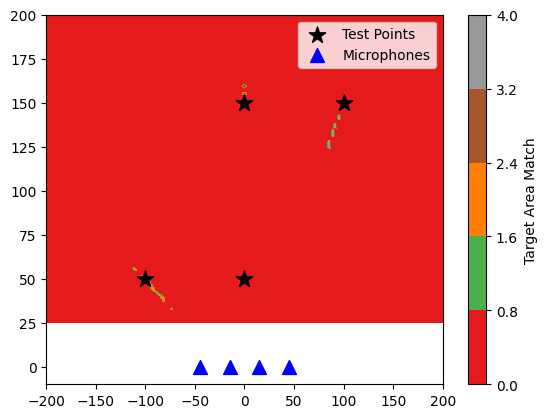

In [152]:
# 1. Baseline initialization enforcing x,y global bounds (-200, 200);(-25,200) and some other variables (e.g., source path)
input:str = r'utils\assignment_2_dataset\train\bird1.mp3'
waveform, sample_rate = torchaudio.load(input)
# 1.2. Averaging out the signal's channels 
mono_waveform = torch.mean(waveform, dim=0) # Apply transformation
mic_locs:list=[(-45, 0), (-15,0), (15, 0),(45,0)]
fixed_locations:list = [(0, 50), (-100, 50), (0, 150), (100, 150)] # List of fixed locations
lb_x, up_x = -200, 200
lb_y, up_y = 25, 200
fixed_locations_time_delays:list=[]
# # 2. Parsing the list holding fixed coordinates and saving their time delays integers;
# # ... Only one song was retained for the sake of simplicity
# 2.1 Building the 2D space
x = np.linspace(lb_x, up_x, 200)
y = np.linspace(lb_y, up_y, 200)
xv, yv = np.meshgrid(x, y) # Return a tuple (`xv` and `yv`) of coordinates matrices from coordinates vectors
z = np.zeros_like(xv) # Create in advance the required z whose dimension matches the 2D tuple of coordinates; could be either of the two xv and yv

# # 3. Parsing over the space coordinates and compare against delays calculated based on fix locations
for loc in fixed_locations:
    _, delays = audio_simulator(mono_waveform, loc, mic_locs)
    # 3.1 Calculate difference relative to the first microphone
    relative_sig = [delays[1]-delays[0], delays[2]-delays[0], delays[3]-delays[0]]
    fixed_locations_time_delays.append(relative_sig)

for i in range(xv.shape[0]):
    for j in range(xv.shape[1]):
        
        pixel_x = xv[i, j]
        pixel_y = yv[i, j]
        
        # Run your simulator for this one pixel to get its 4-mic delay list
        _, delays = audio_simulator(mono_waveform, (pixel_x, pixel_y), mic_locs)
        
        # 5. Check if this pixel perfectly matches any of our 4 target signatures
        # 5.1 Calculate pixel difference relative to the first microphone
        pixel_relative_sig = [delays[1]-delays[0], delays[2]-delays[0], delays[3]-delays[0]]
        # 5.2  compare the relative signatures!
        if pixel_relative_sig == fixed_locations_time_delays[0]:
            z[i, j] = 1
        elif pixel_relative_sig == fixed_locations_time_delays[1]:
            z[i, j] = 2
        elif pixel_relative_sig == fixed_locations_time_delays[2]:
            z[i, j] = 3
        elif pixel_relative_sig == fixed_locations_time_delays[3]:
            z[i, j] = 4
        # If it doesn't match any, it stays 0 (background)

# # 4. Plot
PLT.contourf(xv, yv, z, levels=4, cmap='Set1')
PLT.colorbar(label='Target Area Match')

# # 4.1 Plot the 4 actual test points as black stars so you can see them on the map
test_x = [loc[0] for loc in fixed_locations]
print(fixed_locations)
test_y = [loc[1] for loc in fixed_locations]
PLT.scatter(test_x, test_y, color='black', marker='*', s=150, label='Test Points')

# # 4.2 Plot the 4 microphones as blue triangles
mic_x = [loc[0] for loc in mic_locs]
mic_y = [loc[1] for loc in mic_locs]
PLT.scatter(mic_x, mic_y, color='blue', marker='^', s=100, label='Microphones')

PLT.legend()
PLT.show()

### 2.3.d)

#### Toy CNN Model

In [3]:
class AudioPool(nn.Module):
    """
    Pools along the time dimension using both Mean and Max.
    Preserves spatial/magnitude acoustic cues while preventing validation overfitting.
    """
    def forward(self, x):
        # x shape: [Batch, Channels, Time]
        mean_pool = torch.mean(x, dim=-1)
        max_pool = torch.max(x, dim=-1)[0]  # [0] extracts the actual maximum values tensor
        return torch.cat([mean_pool, max_pool], dim=1)  # Shape: [Batch, Channels * 2]

class DefaultCNN(nn.Module):
    def __init__(self, depth_no_cn_lay: int, width_no_kern: list, stride: list, kernel_size: list, sum: bool = False, input_length: int = 4800):
        super().__init__()
        self.depth = depth_no_cn_lay
        self.width = width_no_kern
        self.sum = sum
        
        # 1. Initialize the sequential container
        self.n = nn.Sequential()
        
        # 2.1 Loop through and build the convolutional layers
        for layer in range(self.depth):
            is_first = (layer == 0)
            
            # 2.2 Dynamic padding calculation based on dilation factor
            dilation_factor = 1 if is_first else 2
            current_kernel = kernel_size[layer]
            padding_val = (current_kernel - 1) * dilation_factor // 2
            
            self.n.append(nn.Conv1d(
                in_channels=width_no_kern[layer], 
                out_channels=width_no_kern[layer+1],
                kernel_size=current_kernel,
                stride=stride[layer], 
                padding=padding_val,
                dilation=dilation_factor,
                # Groups=4 on layer 0 keeps the 4 microphone channels isolated to preserve early TDOA phase cues
                groups=width_no_kern[0] if is_first else 1 
            ))
            self.n.append(nn.BatchNorm1d(width_no_kern[layer+1]))
            self.n.append(nn.LeakyReLU(0.01))

        # Append the advanced multi-pooling block
        self.n.append(AudioPool())
        
        # Calculate the exact linear input size from the final convolutional width
        flattened_features = width_no_kern[-1] * 2

        # Fully connected projection layers to map features to [X, Y] coordinates
        self.fc1 = nn.Linear(flattened_features, 32)
        self.activ = nn.LeakyReLU(negative_slope=0.01)
        self.drop1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(32, 2)
        
        if self.sum:      
            print("Printing summary... ", self.n)

    def forward(self, x):
        x = self.n(x)
        x = self.fc1(x)
        x = self.activ(x) 
        x = self.drop1(x)
        x = self.fc2(x) 
        return x

#### Training design settings and loop initialization

In [12]:
#TODO Add all these variables in a parser
arch = [4, 32, 64, 64]
kernel_sizes = [7, 5, 5]
strides = [1, 2, 2]
mic_locs:list=[(-45, 0), (-15,0), (15, 0),(45,0)]

X_MIN, X_MAX = -200.0, 200.0
Y_MIN, Y_MAX = 25.0, 200.0
mins = torch.tensor([[X_MIN, Y_MIN]], dtype=torch.float32)
maxs = torch.tensor([[X_MAX, Y_MAX]], dtype=torch.float32)
BATCH_SIZE=64
STEPS_PER_EPOCH=40
epochs:int = 20

# Calculate the exact number of samples needed
total_train_samples = BATCH_SIZE * STEPS_PER_EPOCH
# For validation, you usually want fewer steps (e.g., 10 batches) to save time
total_val_samples = BATCH_SIZE * STEPS_PER_EPOCH

train_dataset=CustomAudioDecoderData(t=100,n_sources_min=1, n_sources_max=1, x_loc_min=-200, x_loc_max=200,y_loc_max=200,y_loc_min=25, split='train',mic_locs=mic_locs, data_folder=dataset_roots, transforms=True, dynamic=False, epoch_len=total_train_samples)
val_dataset=CustomAudioDecoderData(t=100,n_sources_min=1, n_sources_max=1, x_loc_min=-200, x_loc_max=200,y_loc_max=200,y_loc_min=25, split='val',mic_locs=mic_locs, data_folder=dataset_roots, transforms=True, dynamic=False, epoch_len=total_val_samples)
test_dataset=CustomAudioDecoderData(t=100,n_sources_min=1, n_sources_max=1, x_loc_min=-200, x_loc_max=200,y_loc_max=200,y_loc_min=25, split='test',mic_locs=mic_locs, data_folder=dataset_roots, transforms=True, dynamic=False, epoch_len=total_val_samples)

trainLoader = DataLoader(train_dataset,batch_size=BATCH_SIZE, shuffle=True)
valLoader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
testLoader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
#TODO Use arg.parser
model = DefaultCNN(3, arch, kernel_size=kernel_sizes, stride=strides,sum=False)
optim = Adam(model.parameters(), lr=0.001, weight_decay=1e-4) 
loss = MSELoss()

train_history, val_history = [], []
train_history_cm, val_history_cm =[], []
for epoch in range(epochs):
    # 1. Training phase
    # 1.1 Initializing training module and loss trackers
    train_loss, val_loss =0.0, 0.0
    train_loss_in_cm, val_loss_in_cm = 0, 0
    model.train()
    for waveform, source_loc in trainLoader:
        # 1.2 Cleaning gradient cache memory and computing the output
        optim.zero_grad()
        _output_tr = model(waveform)
        # 1.3 Normalize the target and compute the loss
        norm_source_loc = normalize_targets(source_loc, mins, maxs)
        _loss_tr = loss(_output_tr, norm_source_loc)
        with torch.no_grad():
            preds_cm = denormalize_predictions(_output_tr, mins, maxs)
            _loss_tr_cm = torch.sqrt(loss(preds_cm, source_loc))
        train_loss +=_loss_tr.item()
        train_loss_in_cm +=_loss_tr_cm.item()
        # 1.4 Undertaking backpropagation~computing the gradients,  
        _loss_tr.backward()
        # ... taking the step, 
        optim.step()
        
        # Debuging Statement 4
        # print("Waveform shape: {}\nSource coordinates and shape: {} {}\n" \
        # "Output shape and content: {} {}\n" \
        # "Loss shape and content: {} {}".format(waveform.shape, 
        #                                        source_loc, source_loc.shape,
        #                                        _output_tr.shape, _output_tr,
        #                                          _loss_tr.shape, _loss_tr.item()))
    
    # 2. Validation phase
    with torch.no_grad():
        model.eval()
        for waveform, source_loc in valLoader:
            norm_source_loc = normalize_targets(source_loc, mins, maxs)
            _output_val = model(waveform)
            _loss_val = loss(_output_val, norm_source_loc)
            preds_val_cm = denormalize_predictions(_output_val, mins, maxs)
            _loss_val_cm = torch.sqrt(loss(preds_val_cm, source_loc))
            val_loss +=_loss_val.item()
            val_loss_in_cm +=_loss_val_cm.item()

    # ... and displaying and saving history (e.g., loss per epoch)
    batch_tr_loss = train_loss/len(trainLoader)
    batch_val_loss = val_loss/len(valLoader)
    batch_tr_loss_cm =  train_loss_in_cm/len(trainLoader)
    batch_val_loss_cm = val_loss_in_cm/len(valLoader)

    train_history_cm.append(batch_tr_loss_cm)
    val_history_cm.append(batch_val_loss_cm)
    train_history.append(batch_tr_loss)
    val_history.append(batch_val_loss)


    print("Epoch no. {}| MSELoss Train {} and CM {}| " \
    "MSELoss Val {} and CM {}".format(epoch,batch_tr_loss,batch_tr_loss_cm, batch_val_loss, batch_val_loss_cm))
    
print("Saving the model")
torch.save(model.state_dict(), r'model_Weights.pth')


Epoch no. 0| MSELoss Train 0.3962149143218994 and CM 93.82109088897705| MSELoss Val 0.31727758795022964 and CM 85.61513061523438
Epoch no. 1| MSELoss Train 0.30857726857066153 and CM 83.42252388000489| MSELoss Val 0.26215177662670613 and CM 75.83382091522216
Epoch no. 2| MSELoss Train 0.2743951238691807 and CM 76.85213871002198| MSELoss Val 0.24361938312649728 and CM 71.97885789871216
Epoch no. 3| MSELoss Train 0.26413562931120393 and CM 74.57402420043945| MSELoss Val 0.23971098847687244 and CM 69.09501132965087
Epoch no. 4| MSELoss Train 0.23847072683274745 and CM 68.28826589584351| MSELoss Val 0.22335962392389774 and CM 67.63261632919311
Epoch no. 5| MSELoss Train 0.23168888911604882 and CM 68.3374532699585| MSELoss Val 0.23965281136333944 and CM 71.16856527328491
Epoch no. 6| MSELoss Train 0.217082866281271 and CM 64.8657374382019| MSELoss Val 0.2264529850333929 and CM 66.73398475646972
Epoch no. 7| MSELoss Train 0.20871106684207916 and CM 62.47486476898193| MSELoss Val 0.2120760802

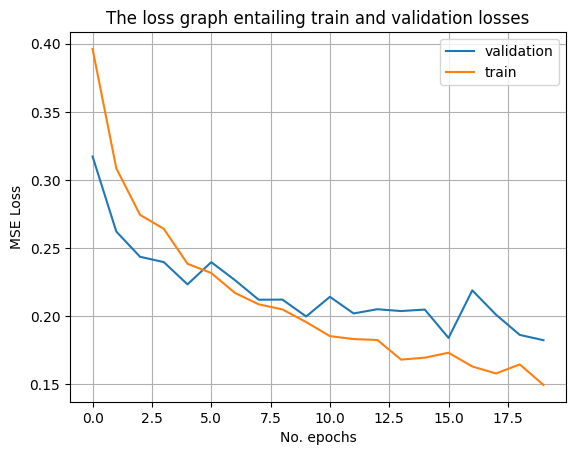

In [28]:
PLT.plot(val_history, label = 'validation')
PLT.plot(train_history, label='train')
PLT.xlabel("No. epochs")
PLT.ylabel("MSE Loss")
PLT.title("The loss graph entailing train and validation losses")
PLT.legend()
PLT.grid()

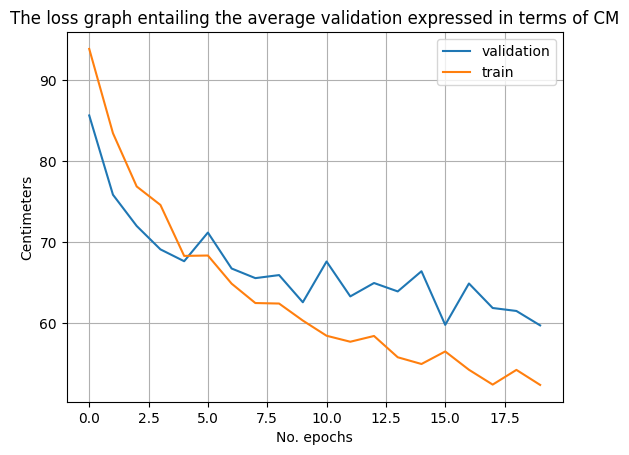

In [29]:
PLT.plot(val_history_cm, label = 'validation')
PLT.plot(train_history_cm, label='train')
PLT.xlabel("No. epochs")
PLT.ylabel("Centimeters")
PLT.title("The loss graph entailing the average validation expressed in terms of CM")
PLT.legend()
PLT.grid()

### 2.3.e)

In [32]:
model = DefaultCNN(3, [4, 32, 64, 64], strides, kernel_sizes,sum=False)
receptive_field = summary(model,(4, 4800), receptive_field=True)

d:\Cristi_s_ground\University\M.L. for signal processing\26-27\.venv\Lib\site-packages\torchscan\modules\flops.py:64: UserWarning: Module type not supported: AudioPool
  warnings.warn(f'Module type not supported: {module.__class__.__name__}')
d:\Cristi_s_ground\University\M.L. for signal processing\26-27\.venv\Lib\site-packages\torchscan\modules\macs.py:51: UserWarning: Module type not supported: AudioPool
  warnings.warn(f'Module type not supported: {module.__class__.__name__}')
d:\Cristi_s_ground\University\M.L. for signal processing\26-27\.venv\Lib\site-packages\torchscan\modules\memory.py:57: UserWarning: Module type not supported: AudioPool
  warnings.warn(f'Module type not supported: {module.__class__.__name__}')
d:\Cristi_s_ground\University\M.L. for signal processing\26-27\.venv\Lib\site-packages\torchscan\modules\receptive.py:46: UserWarning: Module type not supported: AudioPool
  warnings.warn(f'Module type not supported: {module.__class__.__name__}')


____________________________________________________________________________________________________________
Layer                        Type                  Output Shape              Param #         Receptive field
defaultcnn                   DefaultCNN            (-1, 2)                   0               19             
├─n                          Sequential            (-1, 128)                 0               19             
|    └─0                     Conv1d                (-1, 32, 4800)            256             19             
|    └─1                     BatchNorm1d           (-1, 32, 4800)            129             13             
|    └─2                     LeakyReLU             (-1, 32, 4800)            0               13             
|    └─3                     Conv1d                (-1, 64, 2400)            10,304          13             
|    └─4                     BatchNorm1d           (-1, 64, 2400)            257             5              
|    └─5           

### 2.3.f)

In [14]:
# 1.Load the model
arch = [4, 32, 64, 64]
kernel_sizes = [7, 5, 5]
strides = [1, 2, 2]
mic_locs:list=[(-45, 0), (-15,0), (15, 0),(45,0)]

model = DefaultCNN(3, arch, kernel_size=kernel_sizes, stride=strides,sum=False)
optim = Adam(model.parameters(), lr=0.001, weight_decay=1e-4) 
loss = MSELoss()

model = DefaultCNN(3, [4, 32, 64, 64], strides, kernel_sizes, sum=False)
# 2.1 (Optional best practice: add weights_only=True for security)
weights = torch.load('model_Weights.pth', weights_only=True) 
model.load_state_dict(weights)
# 2.2  Set to evaluation mode (only needs to be called once)
model.eval() 
test_loss, test_loss_in_cm = 0.0, 0.0
# 3. Evaluate exactly once 
with torch.no_grad():
    for waveform, source_loc in testLoader: 
        # 3.1 Calculate standard normalized loss
        norm_source_loc = normalize_targets(source_loc, mins, maxs)
        _output_val = model(waveform)
        _loss_val = loss(_output_val, norm_source_loc)
        # 3.2 Calculate real-world Centimeter loss
        preds_val_cm = denormalize_predictions(_output_val, mins, maxs)
        _loss_val_cm = torch.sqrt(loss(preds_val_cm, source_loc))
        # 3.3 Accumulate batch metrics
        test_loss += _loss_val.item()
        test_loss_in_cm += _loss_val_cm.item()

# 4. Average the final metrics
avg_test_loss = test_loss / len(testLoader)
avg_test_loss_cm = test_loss_in_cm / len(testLoader)

print(f"Final Test MSE Loss: {avg_test_loss:.4f}")
print(f"Final Test Error in CM: {avg_test_loss_cm:.2f} cm")

Final Test MSE Loss: 0.2237
Final Test Error in CM: 65.64 cm


In [29]:
# 1.Load the model
arch = [4, 32, 64, 64]
kernel_sizes = [7, 5, 5]
strides = [1, 2, 2]
mic_locs:list=[(-45, 0), (-15,0), (15, 0),(45,0)]
model = DefaultCNN(3, [4, 32, 64, 64], strides, kernel_sizes, sum=False)

# 2.1 (Optional best practice: add weights_only=True for security)
weights = torch.load('model_Weights.pth', weights_only=True) 
model.load_state_dict(weights)

# 2.2  Set to evaluation mode (only needs to be called once)
epochs, test_batch, test_batch_cm=20, [],[]
# 3. Evaluate exactly once 
for epoch in range(epochs):
    test_loss, test_loss_in_cm = 0.0, 0.0
    with torch.no_grad():
        model.eval() 
        for waveform, source_loc in testLoader: 
            # 3.1 Calculate standard normalized loss
            norm_source_loc = normalize_targets(source_loc, mins, maxs)
            _output_val = model(waveform)
            _loss_val = loss(_output_val, norm_source_loc)
            # 3.2 Calculate real-world Centimeter loss
            preds_val_cm = denormalize_predictions(_output_val, mins, maxs)
            _loss_val_cm = torch.sqrt(loss(preds_val_cm, source_loc))
            # 3.3 Accumulate batch metrics
            test_loss += _loss_val.item()
            test_loss_in_cm += _loss_val_cm.item()

    print(f"Epoch {epoch}| Test MSELoss {test_loss/len(testLoader)} and CM {test_loss_in_cm/len(testLoader)}")

    # 4. Average the final metrics
    avg_test_loss = test_loss / len(testLoader)
    test_batch.append(avg_test_loss)
    avg_test_loss_cm = test_loss_in_cm / len(testLoader)
    test_batch_cm.append(avg_test_loss_cm)

Epoch 0| Test MSELoss 0.22433010786771773 and CM 65.82498273849487
Epoch 1| Test MSELoss 0.22248900607228278 and CM 66.85226345062256
Epoch 2| Test MSELoss 0.22021364346146582 and CM 65.06088647842407
Epoch 3| Test MSELoss 0.2276511240750551 and CM 66.62969522476196
Epoch 4| Test MSELoss 0.22523526661098003 and CM 66.70976181030274
Epoch 5| Test MSELoss 0.21756006218492985 and CM 65.3325023651123
Epoch 6| Test MSELoss 0.2183971658349037 and CM 65.23613862991333
Epoch 7| Test MSELoss 0.21499178782105446 and CM 64.4706925392151
Epoch 8| Test MSELoss 0.222597973421216 and CM 66.74771013259888
Epoch 9| Test MSELoss 0.21720368638634682 and CM 64.9071753501892
Epoch 10| Test MSELoss 0.22191732563078403 and CM 66.49165849685669
Epoch 11| Test MSELoss 0.22618300579488276 and CM 67.04519596099854
Epoch 12| Test MSELoss 0.21598735228180885 and CM 64.7781940460205
Epoch 13| Test MSELoss 0.22954353094100952 and CM 66.57646102905274
Epoch 14| Test MSELoss 0.22141279131174088 and CM 65.8715349197387

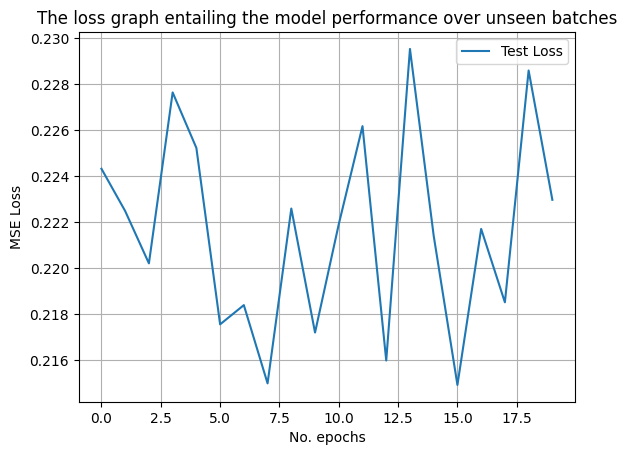

In [30]:
PLT.plot(test_batch, label = 'Test Loss')
PLT.xlabel("No. epochs")
PLT.ylabel("MSE Loss")
PLT.title("The loss graph entailing the model performance over unseen batches")
PLT.legend()
PLT.grid()

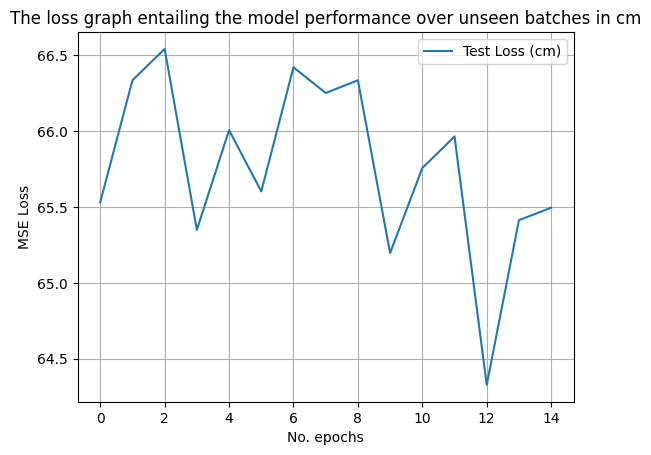

In [21]:
PLT.plot(test_batch_cm, label = 'Test Loss (cm)')
PLT.xlabel("No. epochs")
PLT.ylabel("MSE Loss")
PLT.title("The loss graph entailing the model performance over unseen batches in cm")
PLT.legend()
PLT.grid()

In [31]:
# Extracted lists from the log output (Val mapped to Test as requested)
mse_train = [
    0.3962149143218994, 0.30857726857066153, 0.2743951238691807, 0.26413562931120393, 
    0.23847072683274745, 0.23168888911604882, 0.217082866281271, 0.20871106684207916, 
    0.20496676936745645, 0.1956747815012932, 0.18536293730139733, 0.18319337032735347, 
    0.18253913931548596, 0.16810686681419612, 0.1695467334240675, 0.17317411117255688, 
    0.16306392177939416, 0.15794539488852025, 0.16459256540983916, 0.1495374770835042
]

mse_val = [
    0.31727758795022964, 0.26215177662670613, 0.24361938312649728, 0.23971098847687244, 
    0.22335962392389774, 0.23965281136333944, 0.2264529850333929, 0.21207608021795749, 
    0.21218381524086, 0.19979430474340915, 0.2142154335975647, 0.20201658010482787, 
    0.20510214604437352, 0.2037746708840132, 0.20485297590494156, 0.18403701223433017, 
    0.21894561424851416, 0.20108407661318778, 0.18626872934401034, 0.18235456161201
]


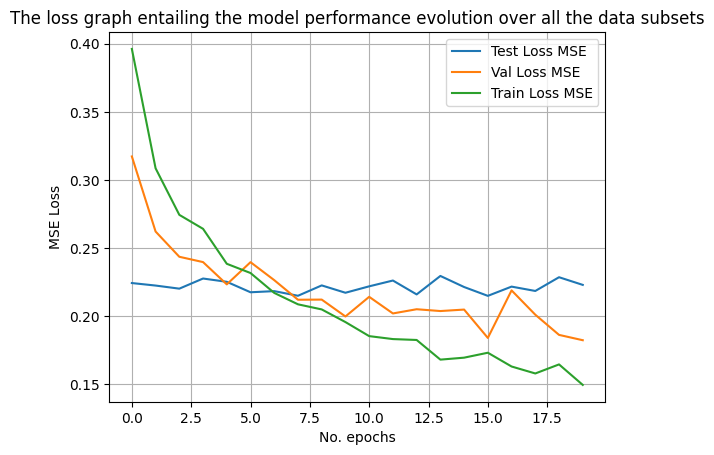

In [32]:
PLT.plot(test_batch, label = 'Test Loss MSE')
PLT.plot(mse_val, label = 'Val Loss MSE')
PLT.plot(mse_train, label = 'Train Loss MSE')
PLT.xlabel("No. epochs")
PLT.ylabel("MSE Loss")
PLT.title("The loss graph entailing the model performance evolution over all the data subsets")
PLT.legend()
PLT.grid()

### 2.3.g)

In [5]:
class AudioPool(nn.Module):
    """
    Pools along the time dimension using both Mean and Max.
    Preserves spatial/magnitude acoustic cues while preventing validation overfitting.
    """
    def forward(self, x):
        # x shape: [Batch, Channels, Time]
        mean_pool = torch.mean(x, dim=-1)
        max_pool = torch.max(x, dim=-1)[0]  # [0] extracts the actual maximum values tensor
        return torch.cat([mean_pool, max_pool], dim=1)  # Shape: [Batch, Channels * 2]

class NSourcesCNN(nn.Module):
    def __init__(self, depth_no_cn_lay: int, width_no_kern: list, stride: list, kernel_size: list, sum: bool = False, input_length: int = 4800):
        super().__init__()
        self.depth = depth_no_cn_lay
        self.width = width_no_kern
        self.sum = sum
        
        # 1. Initialize the sequential container
        self.n = nn.Sequential()
        
        # 2.1 Loop through and build the convolutional layers
        for layer in range(self.depth):
            is_first = (layer == 0)
            
            # 2.2 Dynamic padding calculation based on dilation factor
            dilation_factor = 1 if is_first else 2
            current_kernel = kernel_size[layer]
            padding_val = (current_kernel - 1) * dilation_factor // 2
            
            self.n.append(nn.Conv1d(
                in_channels=width_no_kern[layer], 
                out_channels=width_no_kern[layer+1],
                kernel_size=current_kernel,
                stride=stride[layer], 
                padding=padding_val,
                dilation=dilation_factor,
                # Groups=4 on layer 0 keeps the 4 microphone channels isolated to preserve early TDOA phase cues
                groups=width_no_kern[0] if is_first else 1 
            ))
            self.n.append(nn.BatchNorm1d(width_no_kern[layer+1]))
            self.n.append(nn.LeakyReLU(0.01))

        # Append the advanced multi-pooling block
        self.n.append(AudioPool())
        
        # Calculate the exact linear input size from the final convolutional width
        flattened_features = width_no_kern[-1] * 2

        # Fully connected projection layers to map features to [X, Y] coordinates
        self.fc1 = nn.Linear(flattened_features, 32)
        self.activ = nn.LeakyReLU(negative_slope=0.01)
        self.drop1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(32, 7)
        
        if self.sum:      
            print("Printing summary... ", self.n)

    def forward(self, x):
        x = self.n(x)
        x = self.fc1(x)
        x = self.activ(x) 
        x = self.drop1(x)
        x = self.fc2(x) 
        return x

In [ ]:
# 1.1 Keep in place the architecture design as defined previously
#TODO Wrap all these variables in an argparse instance;
train_history, val_history = [], []
train_history_cm, val_history_cm = [], []
arch, kernel_sizes, strides, mic_locs = [4, 32, 64, 128, 256], [128, 7, 5, 5, 3], [4, 4, 2, 2, 1], [(-45, 0), (-15,0), (15, 0),(45,0)]
epochs:int = 15
model = NSourcesCNN(4, arch, strides, kernel_sizes, sum=False) 
# 1.2 Update mins and maxs to broadcast across 6 coordinate slots (3 sources * 2 coords)
# ... define the space
X_MIN, X_MAX = -200.0, 200.0
Y_MIN, Y_MAX = 25.0, 200.0
mins_2 = torch.tensor([[X_MIN, Y_MIN]], dtype=torch.float32) # Creates tensor of shape (1,2) holding lower bounds coordinates
maxs_2 = torch.tensor([[X_MAX, Y_MAX]], dtype=torch.float32) # -----------------=====------- holding upper bounds cordinates
mins_6 = mins_2.repeat(1, 3) # Repeat [X, Y] three times to match the [X1, Y1, X2, Y2, X3, Y3] shape
maxs_6 = maxs_2.repeat(1, 3)
# 1.3 Define the number of batches and gradient steps
BATCH_SIZE=64
STEPS_PER_EPOCH=40
# 1.4 Calculate the exact number of samples needed
total_train_samples = BATCH_SIZE * STEPS_PER_EPOCH
# 1.5 For validation, you usually want fewer steps (e.g., 10 batches) to save time
total_val_samples = BATCH_SIZE * 10
### 1 ### --------------------------------------------------------------------------

# 2.1 Create a new data retrieval that will hold between 1-3 sources;
train_n_sourcesdataset=CustomAudioDecoderData(t=100,n_sources_min=1, n_sources_max=3, x_loc_min=-200, x_loc_max=200,y_loc_max=200,y_loc_min=25, split='train',mic_locs=mic_locs, data_folder=dataset_roots, transforms=True, dynamic=False, epoch_len=total_train_samples)
val_n_sourcesdataset=CustomAudioDecoderData(t=100,n_sources_min=1, n_sources_max=3, x_loc_min=-200, x_loc_max=200,y_loc_max=200,y_loc_min=25, split='val',mic_locs=mic_locs, data_folder=dataset_roots, transforms=True, dynamic=False, epoch_len=total_val_samples)
test_n_sourcesdataset=CustomAudioDecoderData(t=100,n_sources_min=1, n_sources_max=3, x_loc_min=-200, x_loc_max=200,y_loc_max=200,y_loc_min=25, split='test',mic_locs=mic_locs, data_folder=dataset_roots, transforms=True, dynamic=False, epoch_len=total_val_samples)
# 2.2 Consequently, create new loaders
nsources_trainLoader = DataLoader(train_n_sourcesdataset,batch_size=BATCH_SIZE, shuffle=True)
nsources_valLoader = DataLoader(val_n_sourcesdataset, batch_size=BATCH_SIZE, shuffle=False)
nsources_testLoader = DataLoader(test_n_sourcesdataset, batch_size=BATCH_SIZE, shuffle=False)
### 2 ### --------------------------------------------------------------------------

# 3. Model utils (e.g., Optimizer Initialization)
# 3.1. The Optimizer: AdamW
optim = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
# 3.2. The Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, mode='min', patience=5, factor=0.5)
# 3.3 Use reduction='none' so we a dynamic mask can be applied
loss_fn = nn.MSELoss(reduction='none') 
### 3 ### --------------------------------------------------------------------------


for epoch in range(epochs):
    # -------------------------
    #      TRAINING PHASE     ||
    # -------------------------
    train_loss, train_loss_in_cm = 0.0, 0.0
    model.train()
    for waveform, packed_targets in nsources_trainLoader:
        # 4.1 Clean the gradient cache memory
        optim.zero_grad()
        # 4.2 Unpack the 7-element target tensor
        target_coords = packed_targets[:, :6] # [Batch, 6] -> Max 3X2 sets of (X,Y)
        num_sources = packed_targets[:, 6]    # [Batch] -> Actual number of sources
        
        # 5.1 Forward pass & Split predictions
        _output_tr = model(waveform)
        pred_coords = _output_tr[:, :6] # [Batch, 6] -> Max 3X2 predicted sets of (X,Y)
        pred_count = _output_tr[:, 6]   # [Batch] -> Predicted number of sources
        # 5.2 Vectorized Mask Creation (Turns n_sources into [1,1, 0,0, 0,0] binary masks)
        batch_size = num_sources.size(0) # 
        idx = torch.arange(6, device=waveform.device).unsqueeze(0).expand(batch_size, 6)
        active_lengths = (num_sources * 2).unsqueeze(1)
        mask = (idx < active_lengths).float() # Shape: [Batch, 6]
        # 5.3 Normalize targets and compute raw coordinate loss
        norm_target_coords = normalize_targets(target_coords, mins_6, maxs_6)
        raw_coord_loss = loss_fn(pred_coords, norm_target_coords)
        # 5.4 Apply mask to ignore dummy coordinates, then average only over active sources
        masked_coord_loss = raw_coord_loss * mask
        loss_coords = torch.sum(masked_coord_loss) / torch.sum(mask).clamp_min(1e-8)
        # 5.5. Compute Source Count Loss (Standard MSE)
        loss_count = torch.mean((pred_count - num_sources) ** 2)
        # 5.6 Total Backpropagation Loss
        _loss_tr = loss_coords + (0.05 * loss_count)
        
        # 6. CM Error Calculation (Masked to ignore dummy coordinates)
        with torch.no_grad():
            preds_cm = denormalize_predictions(pred_coords, mins_6, maxs_6)
            raw_cm_loss = loss_fn(preds_cm, target_coords)
            masked_cm_loss = raw_cm_loss * mask
            _loss_tr_cm = torch.sqrt(torch.sum(masked_cm_loss) / torch.sum(mask).clamp_min(1e-8))
            
        train_loss += _loss_tr.item()
        train_loss_in_cm += _loss_tr_cm.item()
        _loss_tr.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optim.step()
    
    # ---------------------
    #     VALIDATION PHASE |
    # ---------------------
    val_loss, val_loss_in_cm = 0.0, 0.0
    
    with torch.no_grad():
        model.eval()
        for waveform, packed_targets in nsources_valLoader:
            # 7. The same steps are executed as before
            # 7.1 No. of sources and coordinates retrieval
            target_coords = packed_targets[:, :6]
            num_sources = packed_targets[:, 6]
            _output_val = model(waveform)
            pred_coords = _output_val[:, :6]
            pred_count = _output_val[:, 6]
            
            # 7.2 Mask Creation
            batch_size = num_sources.size(0)
            idx = torch.arange(6, device=waveform.device).unsqueeze(0).expand(batch_size, 6)
            active_lengths = (num_sources * 2).unsqueeze(1)
            mask = (idx < active_lengths).float()
            # 7.3 Masked Val Coordinate Loss
            norm_target_coords = normalize_targets(target_coords, mins_6, maxs_6)
            masked_coord_loss = loss_fn(pred_coords, norm_target_coords) * mask
            loss_coords = torch.sum(masked_coord_loss) / torch.sum(mask).clamp_min(1e-8)
            # 7.4 Val Count Loss
            loss_count = torch.mean((pred_count - num_sources) ** 2)
            _loss_val = loss_coords + (0.05 * loss_count)
            
            # 7.5 Val CM Error
            preds_cm = denormalize_predictions(pred_coords, mins_6, maxs_6)
            masked_cm_loss = loss_fn(preds_cm, target_coords) * mask
            _loss_val_cm = torch.sqrt(torch.sum(masked_cm_loss) / torch.sum(mask).clamp_min(1e-8))
            val_loss += _loss_val.item()
            val_loss_in_cm += _loss_val_cm.item()

    # --------------------
    #   METRICS & SCHEDULING|
    # -----------------------
    batch_tr_loss = train_loss / len(nsources_trainLoader)
    batch_val_loss = val_loss / len(nsources_valLoader)
    batch_tr_loss_cm = train_loss_in_cm / len(nsources_trainLoader)
    batch_val_loss_cm = val_loss_in_cm / len(nsources_valLoader)

    train_history_cm.append(batch_tr_loss_cm)
    val_history_cm.append(batch_val_loss_cm)
    train_history.append(batch_tr_loss)
    val_history.append(batch_val_loss)
    
    # Step the learning rate scheduler based on validation loss
    scheduler.step(batch_val_loss)

    print("Epoch no. {}| MSE Train {:.4f} and CM {:.2f} | MSE Val {:.4f} and CM {:.2f} | LR: {:.6f}".format(
        epoch, batch_tr_loss, batch_tr_loss_cm, batch_val_loss, batch_val_loss_cm, optim.param_groups[0]['lr']))
    
torch.save(model.state_dict(), 'N_sources_model_weights.pth')

Epoch no. 0| MSE Train 0.3980 and CM 84.87 | MSE Val 0.3257 and CM 73.12 | LR: 0.001000
Epoch no. 1| MSE Train 0.3278 and CM 75.14 | MSE Val 0.2849 and CM 69.96 | LR: 0.001000
Epoch no. 2| MSE Train 0.2954 and CM 70.63 | MSE Val 0.2730 and CM 67.10 | LR: 0.001000
Epoch no. 3| MSE Train 0.2929 and CM 69.99 | MSE Val 0.2765 and CM 67.34 | LR: 0.001000
Epoch no. 4| MSE Train 0.2916 and CM 69.63 | MSE Val 0.2698 and CM 66.25 | LR: 0.001000
Epoch no. 5| MSE Train 0.2775 and CM 67.05 | MSE Val 0.2660 and CM 66.55 | LR: 0.001000
Epoch no. 6| MSE Train 0.2804 and CM 68.53 | MSE Val 0.2594 and CM 65.05 | LR: 0.001000
Epoch no. 7| MSE Train 0.2730 and CM 67.19 | MSE Val 0.2645 and CM 67.00 | LR: 0.001000
Epoch no. 8| MSE Train 0.2727 and CM 67.43 | MSE Val 0.2597 and CM 64.98 | LR: 0.001000
Epoch no. 9| MSE Train 0.2680 and CM 66.63 | MSE Val 0.2603 and CM 66.68 | LR: 0.001000
Epoch no. 10| MSE Train 0.2717 and CM 67.38 | MSE Val 0.2608 and CM 64.85 | LR: 0.001000
Epoch no. 11| MSE Train 0.2658 

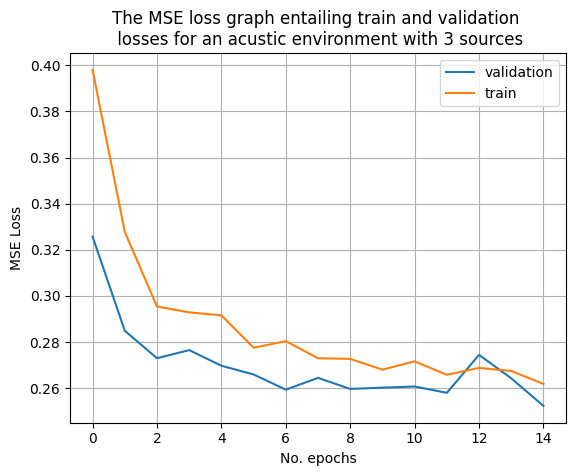

In [42]:
PLT.plot(val_history, label = 'validation')
PLT.plot(train_history, label='train')
PLT.xlabel("No. epochs")
PLT.ylabel("MSE Loss")
PLT.title("The MSE loss graph entailing train and validation \n losses for an acustic environment with 3 sources")
PLT.savefig(r'Submission\utils\results\The loss graph entailing train and validation losses for an acustic environment with 3 sources')
PLT.legend()
PLT.grid()

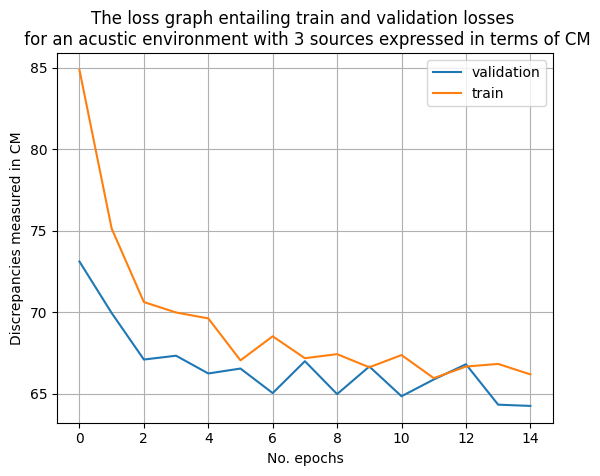

In [40]:
PLT.plot(val_history_cm, label = 'validation')
PLT.plot(train_history_cm, label='train')
PLT.xlabel("No. epochs")
PLT.ylabel("Discrepancies measured in CM")
PLT.title("The loss graph entailing train and validation losses \n for an acustic environment with 3 sources expressed in terms of CM")
PLT.savefig(r'Submission\utils\results\The loss graph entailing train and validation losses for an acustic environment with 3 sources')
PLT.legend()
PLT.grid()

### 2.3.i)

In [21]:
# 1.Load the model
arch, kernel_sizes, strides, mic_locs = [4, 32, 64, 128, 256], [128, 7, 5, 5, 3], [4, 4, 2, 2, 1], [(-45, 0), (-15,0), (15, 0),(45,0)]
model = NSourcesCNN(4, arch, strides, kernel_sizes, sum=False) 

# 2.1 (Optional best practice: add weights_only=True for security)
weights = torch.load(r'Submission\utils\results\N_sources_model_weights.pth', weights_only=True) 
model.load_state_dict(weights)

X_MIN, X_MAX = -200.0, 200.0
Y_MIN, Y_MAX = 25.0, 200.0
mins_2 = torch.tensor([[X_MIN, Y_MIN]], dtype=torch.float32) # Creates tensor of shape (1,2) holding lower bounds coordinates
maxs_2 = torch.tensor([[X_MAX, Y_MAX]], dtype=torch.float32) # -----------------=====------- holding upper bounds cordinates
mins_6 = mins_2.repeat(1, 3) # Repeat [X, Y] three times to match the [X1, Y1, X2, Y2, X3, Y3] shape
maxs_6 = maxs_2.repeat(1, 3)

# 2.2  Set to evaluation mode (only needs to be called once)
epochs, test_batch, test_batch_cm=15, [],[]
# 3. Evaluate exactly once 
for epoch in range(epochs):
    test_loss, test_loss_in_cm = 0.0, 0.0    
    with torch.no_grad():
        model.eval()
        for waveform, packed_targets in nsources_testLoader:
            # 7. The same steps are executed as before
            # 7.1 No. of sources and coordinates retrieval
            target_coords = packed_targets[:, :6]
            num_sources = packed_targets[:, 6]
            _output_val = model(waveform)
            pred_coords = _output_val[:, :6]
            pred_count = _output_val[:, 6]
            # 7.2 Mask Creation
            batch_size = num_sources.size(0)
            idx = torch.arange(6, device=waveform.device).unsqueeze(0).expand(batch_size, 6)
            active_lengths = (num_sources * 2).unsqueeze(1)
            mask = (idx < active_lengths).float()
            # 7.3 Masked Val Coordinate Loss
            norm_target_coords = normalize_targets(target_coords, mins_6, maxs_6)
            masked_coord_loss = loss_fn(pred_coords, norm_target_coords) * mask
            loss_coords = torch.sum(masked_coord_loss) / torch.sum(mask).clamp_min(1e-8)
            # 7.4 Val Count Loss
            loss_count = torch.mean((pred_count - num_sources) ** 2)
            _test_val = loss_coords + (0.05 * loss_count)
            
            # 7.5 Val CM Error
            preds_cm = denormalize_predictions(pred_coords, mins_6, maxs_6)
            masked_cm_loss = loss_fn(preds_cm, target_coords) * mask
            _test_val_cm = torch.sqrt(torch.sum(masked_cm_loss) / torch.sum(mask).clamp_min(1e-8))
            test_loss += _test_val.item()
            test_loss_in_cm += _test_val_cm.item()

    print(f"Epoch {epoch}| Test MSELoss {test_loss/len(nsources_testLoader)} and CM {test_loss_in_cm/len(nsources_testLoader)}")

    # 4. Average the final metrics
    avg_test_loss = test_loss / len(nsources_testLoader)
    test_batch.append(avg_test_loss)
    avg_test_loss_cm = test_loss_in_cm / len(nsources_testLoader)
    test_batch_cm.append(avg_test_loss_cm)

Epoch 0| Test MSELoss 0.28194199204444886 and CM 71.51917953491211
Epoch 1| Test MSELoss 0.28714669197797776 and CM 71.703759765625
Epoch 2| Test MSELoss 0.28701967000961304 and CM 72.79725189208985
Epoch 3| Test MSELoss 0.276060064136982 and CM 70.15966186523437
Epoch 4| Test MSELoss 0.2881339520215988 and CM 70.8597396850586
Epoch 5| Test MSELoss 0.28985159397125243 and CM 71.19033203125
Epoch 6| Test MSELoss 0.28223176300525665 and CM 71.3294563293457
Epoch 7| Test MSELoss 0.2742833346128464 and CM 70.14098815917968
Epoch 8| Test MSELoss 0.2850962162017822 and CM 70.84599075317382
Epoch 9| Test MSELoss 0.2924480319023132 and CM 70.8968894958496
Epoch 10| Test MSELoss 0.2846889391541481 and CM 71.32126998901367
Epoch 11| Test MSELoss 0.27640397250652315 and CM 69.86210250854492
Epoch 12| Test MSELoss 0.28826584219932555 and CM 72.07829284667969
Epoch 13| Test MSELoss 0.27634118795394896 and CM 67.97387351989747
Epoch 14| Test MSELoss 0.2853447884321213 and CM 70.95337257385253


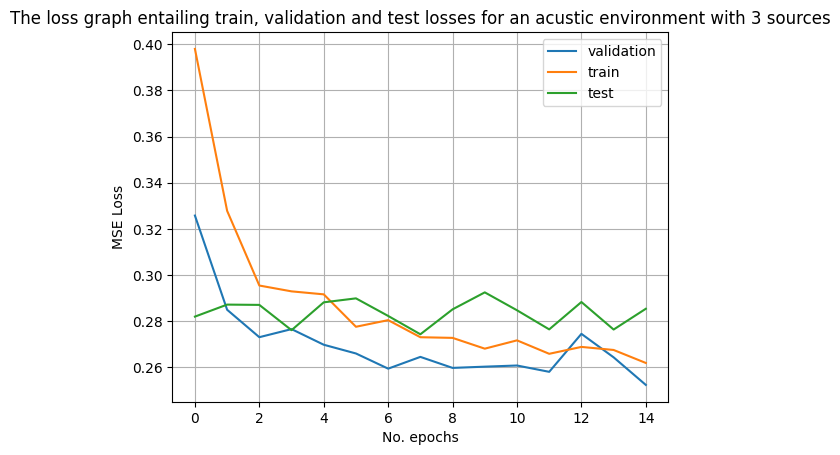

In [ ]:
PLT.plot(val_history, label = 'validation')
PLT.plot(train_history, label='train')
PLT.xlabel("No. epochs")
PLT.ylabel("MSE Loss")
PLT.title("The loss graph entailing train, validation and test losses for an acustic environment with 3 sources")
PLT.savefig(r'Submission\utils\results\The loss graph entailing train and validation losses for an acustic environment with 3 sources')
PLT.legend()
PLT.grid()

In [ ]:
# 1.Load the model
arch, kernel_sizes, strides, mic_locs = [4, 32, 64, 128, 256], [128, 7, 5, 5, 3], [4, 4, 2, 2, 1], [(-45, 0), (-15,0), (15, 0),(45,0)]
model = NSourcesCNN(4, arch, strides, kernel_sizes, sum=False) 


# 2.1 Create a new data retrieval that will hold between 1-3 sources;
train_2_sourcesdataset=CustomAudioDecoderData(t=100,n_sources_min=1, n_sources_max=2, x_loc_min=-200, x_loc_max=200,y_loc_max=200,y_loc_min=25, split='train',mic_locs=mic_locs, data_folder=dataset_roots, transforms=True, dynamic=False, epoch_len=total_train_samples)
val_2_sourcesdataset=CustomAudioDecoderData(t=100,n_sources_min=1, n_sources_max=2, x_loc_min=-200, x_loc_max=200,y_loc_max=200,y_loc_min=25, split='val',mic_locs=mic_locs, data_folder=dataset_roots, transforms=True, dynamic=False, epoch_len=total_val_samples)
test_2_sourcesdataset=CustomAudioDecoderData(t=100,n_sources_min=1, n_sources_max=2, x_loc_min=-200, x_loc_max=200,y_loc_max=200,y_loc_min=25, split='test',mic_locs=mic_locs, data_folder=dataset_roots, transforms=True, dynamic=False, epoch_len=total_val_samples)
# 2.2 Consequently, create new loaders
n2sources_trainLoader = DataLoader(train_2_sourcesdataset,batch_size=BATCH_SIZE, shuffle=True)
n2sources_valLoader = DataLoader(val_2_sourcesdataset, batch_size=BATCH_SIZE, shuffle=False)
n2sources_testLoader = DataLoader(test_2_sourcesdataset, batch_size=BATCH_SIZE, shuffle=False)

# 2.1 (Optional best practice: add weights_only=True for security)
weights = torch.load(r'Submission\utils\results\N_sources_model_weights.pth', weights_only=True) 
model.load_state_dict(weights)

X_MIN, X_MAX = -200.0, 200.0
Y_MIN, Y_MAX = 25.0, 200.0
mins_2 = torch.tensor([[X_MIN, Y_MIN]], dtype=torch.float32) # Creates tensor of shape (1,2) holding lower bounds coordinates
maxs_2 = torch.tensor([[X_MAX, Y_MAX]], dtype=torch.float32) # -----------------=====------- holding upper bounds cordinates
mins_6 = mins_2.repeat(1, 3) # Repeat [X, Y] three times to match the [X1, Y1, X2, Y2, X3, Y3] shape
maxs_6 = maxs_2.repeat(1, 3)

# 2.2  Set to evaluation mode (only needs to be called once)
epochs, test_2batch, test_2batch_cm=15, [],[]
# 3. Evaluate exactly once 
for epoch in range(epochs):
    test_loss, test_loss_in_cm = 0.0, 0.0    
    with torch.no_grad():
        model.eval()
        for waveform, packed_targets in n2sources_testLoader:
            # 7. The same steps are executed as before
            # 7.1 No. of sources and coordinates retrieval
            target_coords = packed_targets[:, :6]
            num_sources = packed_targets[:, 6]
            _output_val = model(waveform)
            pred_coords = _output_val[:, :6]
            pred_count = _output_val[:, 6]
            # 7.2 Mask Creation
            batch_size = num_sources.size(0)
            idx = torch.arange(6, device=waveform.device).unsqueeze(0).expand(batch_size, 6)
            active_lengths = (num_sources * 2).unsqueeze(1)
            mask = (idx < active_lengths).float()
            # 7.3 Masked Val Coordinate Loss
            norm_target_coords = normalize_targets(target_coords, mins_6, maxs_6)
            masked_coord_loss = loss_fn(pred_coords, norm_target_coords) * mask
            loss_coords = torch.sum(masked_coord_loss) / torch.sum(mask).clamp_min(1e-8)
            # 7.4 Val Count Loss
            loss_count = torch.mean((pred_count - num_sources) ** 2)
            _test_val = loss_coords + (0.05 * loss_count)
            
            # 7.5 Val CM Error
            preds_cm = denormalize_predictions(pred_coords, mins_6, maxs_6)
            masked_cm_loss = loss_fn(preds_cm, target_coords) * mask
            _test_val_cm = torch.sqrt(torch.sum(masked_cm_loss) / torch.sum(mask).clamp_min(1e-8))
            test_loss += _test_val.item()
            test_loss_in_cm += _test_val_cm.item()

    print(f"Epoch {epoch}| Test MSELoss {test_loss/len(nsources_testLoader)} and CM {test_loss_in_cm/len(nsources_testLoader)}")

    # 4. Average the final metrics
    avg_test_loss = test_loss / len(nsources_testLoader)
    test_2batch.append(avg_test_loss)
    avg_test_loss_cm = test_loss_in_cm / len(nsources_testLoader)
    test_2batch_cm.append(avg_test_loss_cm)

Epoch 0| Test MSELoss 0.2683299943804741 and CM 71.50912017822266
Epoch 1| Test MSELoss 0.2636823639273643 and CM 70.56125183105469
Epoch 2| Test MSELoss 0.26730490624904635 and CM 72.09926147460938
Epoch 3| Test MSELoss 0.2695539191365242 and CM 72.89661560058593
Epoch 4| Test MSELoss 0.2617682352662086 and CM 71.6033935546875
Epoch 5| Test MSELoss 0.2657857283949852 and CM 71.42012596130371
Epoch 6| Test MSELoss 0.25661601126194 and CM 69.67439689636231
Epoch 7| Test MSELoss 0.2742931693792343 and CM 71.1472728729248
Epoch 8| Test MSELoss 0.271238648891449 and CM 71.67447052001953
Epoch 9| Test MSELoss 0.26284040659666064 and CM 70.14544372558593
Epoch 10| Test MSELoss 0.2620443984866142 and CM 70.2083251953125
Epoch 11| Test MSELoss 0.25335461348295213 and CM 69.29164047241211
Epoch 12| Test MSELoss 0.2671246290206909 and CM 70.71912689208985
Epoch 13| Test MSELoss 0.27124944031238557 and CM 72.01346969604492
Epoch 14| Test MSELoss 0.2726766884326935 and CM 71.58446044921875


In [ ]:
# 1.Load the model
        model = NSourcesCNN(4, args.complex_arch[0], args.complex_arch[2], args.complex_arch[1], sum=False) 
        for n_source in range(3):

            # 2.1 Create a new data retrieval that will hold between 1-3 sources;
            train_1_sourcesdataset=CustomAudioDecoderData(t=100,n_sources_min=1, n_sources_max=n_source+1, x_loc_min=-200, x_loc_max=200,y_loc_max=200,y_loc_min=25, split='train',mic_locs=mic_locs, data_folder=args.DATASET_ROOTS, transforms=True, dynamic=False, epoch_len=total_train_samples)
            val_1_sourcesdataset=CustomAudioDecoderData(t=100,n_sources_min=1, n_sources_max=n_source+1, x_loc_min=-200, x_loc_max=200,y_loc_max=200,y_loc_min=25, split='val',mic_locs=mic_locs, data_folder=args.DATASET_ROOTS, transforms=True, dynamic=False, epoch_len=total_val_samples)
            test_1_sourcesdataset=CustomAudioDecoderData(t=100,n_sources_min=1, n_sources_max=n_source+1, x_loc_min=-200, x_loc_max=200,y_loc_max=200,y_loc_min=25, split='test',mic_locs=mic_locs, data_folder=args.DATASET_ROOTS, transforms=True, dynamic=False, epoch_len=total_val_samples)
            # 2.2 Consequently, create new loaders
            n1sources_trainLoader = DataLoader(train_1_sourcesdataset,batch_size=args.BATCH_SIZE, shuffle=True)
            n1sources_valLoader = DataLoader(val_1_sourcesdataset, batch_size=args.BATCH_SIZE, shuffle=False)
            n1sources_testLoader = DataLoader(test_1_sourcesdataset, batch_size=args.BATCH_SIZE, shuffle=False)

            # 2.1 (Optional best practice: add weights_only=True for security)
            weights = torch.load(r'utils\results\N_sources_model_weights.pth', weights_only=True) 
            model.load_state_dict(weights)

            X_MIN, X_MAX = -200.0, 200.0
            Y_MIN, Y_MAX = 25.0, 200.0
            mins_2 = torch.tensor([[X_MIN, Y_MIN]], dtype=torch.float32) # Creates tensor of shape (1,2) holding lower bounds coordinates
            maxs_2 = torch.tensor([[X_MAX, Y_MAX]], dtype=torch.float32) # -----------------=====------- holding upper bounds cordinates
            mins_6 = mins_2.repeat(1, 3) # Repeat [X, Y] three times to match the [X1, Y1, X2, Y2, X3, Y3] shape
            maxs_6 = maxs_2.repeat(1, 3)

            # 2.2  Set to evaluation mode (only needs to be called once)
            epochs, test_1batch, test_1batch_cm=15, [],[]
            # 3. Evaluate exactly once 
            # 3. Evaluate exactly once 
            test_loss, test_loss_in_cm = 0.0, 0.0    
            with torch.no_grad():
                model.eval()
                for waveform, raw_targets in n1sources_testLoader:
                    
                    # --- NEW PADDING LOGIC ---
                    batch_size_curr = raw_targets.size(0)
                    target_len = raw_targets.size(1)
                    
                    if target_len < 7:
                        # 1. Figure out how many sources this is (e.g., length 2 = 1 source)
                        actual_n_sources = target_len // 2
                        count_tensor = torch.full((batch_size_curr, 1), actual_n_sources, dtype=torch.float32, device=raw_targets.device)
                        
                        # 2. Create the 6-coordinate placeholder filled with zeros
                        padded_coords = torch.zeros((batch_size_curr, 6), dtype=torch.float32, device=raw_targets.device)
                        
                        # 3. Copy the valid coordinates into the placeholder
                        padded_coords[:, :target_len] = raw_targets
                        
                        # 4. Stitch it together to recreate the 7-element tensor
                        packed_targets = torch.cat([padded_coords, count_tensor], dim=1)
                    else:
                        packed_targets = raw_targets
                    # -------------------------

                    # 7.1 No. of sources and coordinates retrieval (Now perfectly safe!)
                    target_coords = packed_targets[:, :6]
                    num_sources = packed_targets[:, 6]
                    
                    _output_val = model(waveform)
                    pred_coords = _output_val[:, :6]
                    pred_count = _output_val[:, 6]
                    
                    # 7.2 Mask Creation
                    batch_size = num_sources.size(0)
                    idx = torch.arange(6, device=waveform.device).unsqueeze(0).expand(batch_size, 6)
                    active_lengths = (num_sources * 2).unsqueeze(1)
                    mask = (idx < active_lengths).float()
                    
                    # 7.3 Masked Val Coordinate Loss
                    norm_target_coords = normalize_targets(target_coords, mins_6, maxs_6)
                    masked_coord_loss = loss(pred_coords, norm_target_coords) * mask
                    loss_coords = torch.sum(masked_coord_loss) / torch.sum(mask).clamp_min(1e-8)
                    
                    # 7.4 Val Count Loss
                    loss_count = torch.mean((pred_count - num_sources) ** 2)
                    _test_val = loss_coords + (0.05 * loss_count)
                    
                    # 7.5 Val CM Error
                    preds_cm = denormalize_predictions(pred_coords, mins_6, maxs_6)
                    masked_cm_loss = loss(preds_cm, target_coords) * mask
                    _test_val_cm = torch.sqrt(torch.sum(masked_cm_loss) / torch.sum(mask).clamp_min(1e-8))
                    
                    test_loss += _test_val.item()
                    test_loss_in_cm += _test_val_cm.item()

            # 4. Average the final metrics (Fixed the variable name here to n1sources_testLoader!)
            avg_test_loss = test_loss / len(n1sources_testLoader)
            test_1batch.append(avg_test_loss)
            
            avg_test_loss_cm = test_loss_in_cm / len(n1sources_testLoader)
            test_1batch_cm.append(avg_test_loss_cm)

            print(f"Final Test MSE Loss with {n_source+1} source: {avg_test_loss:.4f}")
            print(f"Final Test Error in CM with {n_source+1} source: {avg_test_loss_cm:.2f} cm")

Epoch 0| Test MSELoss 0.26492014676332476 and CM 71.32060890197754
Epoch 1| Test MSELoss 0.2521427199244499 and CM 68.08260574340821
Epoch 2| Test MSELoss 0.2608778774738312 and CM 70.46895904541016
Epoch 3| Test MSELoss 0.2530649334192276 and CM 68.59886245727539
Epoch 4| Test MSELoss 0.265621118247509 and CM 70.93626022338867
Epoch 5| Test MSELoss 0.2534247100353241 and CM 69.50551376342773
Epoch 6| Test MSELoss 0.25006312876939774 and CM 68.72917098999024
Epoch 7| Test MSELoss 0.2689185574650764 and CM 71.56246414184571
Epoch 8| Test MSELoss 0.26906912326812743 and CM 71.84008712768555
Epoch 9| Test MSELoss 0.2734172612428665 and CM 71.87265701293946
Epoch 10| Test MSELoss 0.26171348094940183 and CM 69.95728950500488
Epoch 11| Test MSELoss 0.26592835038900375 and CM 70.808447265625
Epoch 12| Test MSELoss 0.275112746655941 and CM 71.9658103942871
Epoch 13| Test MSELoss 0.26615277081727984 and CM 71.9826774597168
Epoch 14| Test MSELoss 0.26371586322784424 and CM 71.56822052001954


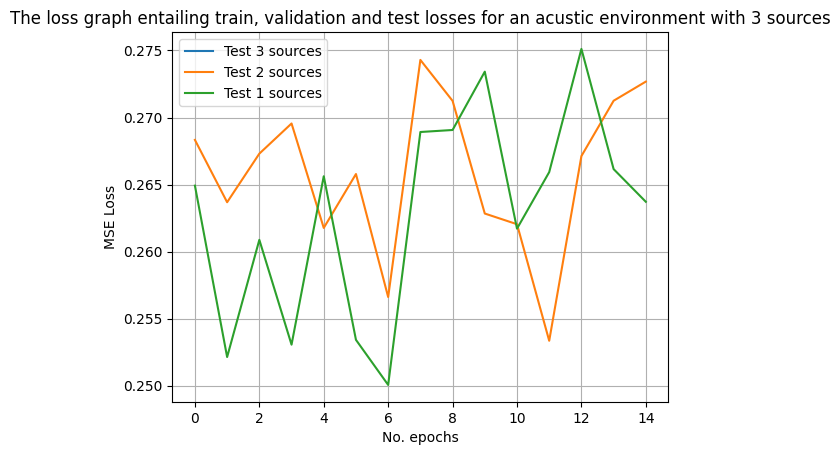

In [31]:
PLT.plot(test_batch, label = 'Test 3 sources')
PLT.plot(test_2batch, label='Test 2 sources')
PLT.plot(test_1batch, label='Test 1 sources')
PLT.xlabel("No. epochs")
PLT.ylabel("MSE Loss")
PLT.title("The loss graph entailing train, validation and test losses for an acustic environment with 3 sources")
PLT.savefig(r'Submission\utils\results\The loss graph entailing train and validation losses for an acustic environment with 3 sources')
PLT.legend()
PLT.grid()

In [66]:
# 1.Load the model
arch, kernel_sizes, strides, mic_locs = [4, 32, 64, 128, 256], [128, 7, 5, 5, 3], [4, 4, 2, 2, 1], [(-45, 0), (-15,0), (15, 0),(45,0)]
model = NSourcesCNN(4, arch, strides, kernel_sizes, sum=False) 

for n_source in range(3):

    # 2.1 Create a new data retrieval that will hold between 1-3 sources;
    train_1_sourcesdataset=CustomAudioDecoderData(t=100,n_sources_min=1, n_sources_max=n_source+1, x_loc_min=-200, x_loc_max=200,y_loc_max=200,y_loc_min=25, split='train',mic_locs=mic_locs, data_folder=dataset_roots, transforms=True, dynamic=False, epoch_len=total_train_samples)
    val_1_sourcesdataset=CustomAudioDecoderData(t=100,n_sources_min=1, n_sources_max=n_source+1, x_loc_min=-200, x_loc_max=200,y_loc_max=200,y_loc_min=25, split='val',mic_locs=mic_locs, data_folder=dataset_roots, transforms=True, dynamic=False, epoch_len=total_val_samples)
    test_1_sourcesdataset=CustomAudioDecoderData(t=100,n_sources_min=1, n_sources_max=n_source+1, x_loc_min=-200, x_loc_max=200,y_loc_max=200,y_loc_min=25, split='test',mic_locs=mic_locs, data_folder=dataset_roots, transforms=True, dynamic=False, epoch_len=total_val_samples)
    # 2.2 Consequently, create new loaders
    n1sources_trainLoader = DataLoader(train_1_sourcesdataset,batch_size=BATCH_SIZE, shuffle=True)
    n1sources_valLoader = DataLoader(val_1_sourcesdataset, batch_size=BATCH_SIZE, shuffle=False)
    n1sources_testLoader = DataLoader(test_1_sourcesdataset, batch_size=BATCH_SIZE, shuffle=False)

    # 2.1 (Optional best practice: add weights_only=True for security)
    weights = torch.load(r'Submission\utils\results\N_sources_model_weights.pth', weights_only=True) 
    model.load_state_dict(weights)

    X_MIN, X_MAX = -200.0, 200.0
    Y_MIN, Y_MAX = 25.0, 200.0
    mins_2 = torch.tensor([[X_MIN, Y_MIN]], dtype=torch.float32) # Creates tensor of shape (1,2) holding lower bounds coordinates
    maxs_2 = torch.tensor([[X_MAX, Y_MAX]], dtype=torch.float32) # -----------------=====------- holding upper bounds cordinates
    mins_6 = mins_2.repeat(1, 3) # Repeat [X, Y] three times to match the [X1, Y1, X2, Y2, X3, Y3] shape
    maxs_6 = maxs_2.repeat(1, 3)

    # 2.2  Set to evaluation mode (only needs to be called once)
    epochs, test_1batch, test_1batch_cm=15, [],[]
    # 3. Evaluate exactly once 
    test_loss, test_loss_in_cm = 0.0, 0.0    
    with torch.no_grad():
        model.eval()
        for waveform, raw_targets in n1sources_testLoader:
            
            # --- NEW PADDING LOGIC ---
            batch_size_curr = raw_targets.size(0)
            target_len = raw_targets.size(1)
            
            if target_len < 7:
                # 1. Figure out how many sources this is (e.g., length 2 = 1 source)
                actual_n_sources = target_len // 2
                count_tensor = torch.full((batch_size_curr, 1), actual_n_sources, dtype=torch.float32, device=raw_targets.device)
                
                # 2. Create the 6-coordinate placeholder filled with zeros
                padded_coords = torch.zeros((batch_size_curr, 6), dtype=torch.float32, device=raw_targets.device)
                
                # 3. Copy the valid coordinates into the placeholder
                padded_coords[:, :target_len] = raw_targets
                
                # 4. Stitch it together to recreate the 7-element tensor
                packed_targets = torch.cat([padded_coords, count_tensor], dim=1)
            else:
                packed_targets = raw_targets
            # -------------------------

            # 7.1 No. of sources and coordinates retrieval (Now perfectly safe!)
            target_coords = packed_targets[:, :6]
            num_sources = packed_targets[:, 6]
            
            _output_val = model(waveform)
            pred_coords = _output_val[:, :6]
            pred_count = _output_val[:, 6]
            
            # 7.2 Mask Creation
            batch_size = num_sources.size(0)
            idx = torch.arange(6, device=waveform.device).unsqueeze(0).expand(batch_size, 6)
            active_lengths = (num_sources * 2).unsqueeze(1)
            mask = (idx < active_lengths).float()
            
            # 7.3 Masked Val Coordinate Loss
            norm_target_coords = normalize_targets(target_coords, mins_6, maxs_6)
            masked_coord_loss = loss_fn(pred_coords, norm_target_coords) * mask
            loss_coords = torch.sum(masked_coord_loss) / torch.sum(mask).clamp_min(1e-8)
            
            # 7.4 Val Count Loss
            loss_count = torch.mean((pred_count - num_sources) ** 2)
            _test_val = loss_coords + (0.05 * loss_count)
            
            # 7.5 Val CM Error
            preds_cm = denormalize_predictions(pred_coords, mins_6, maxs_6)
            masked_cm_loss = loss_fn(preds_cm, target_coords) * mask
            _test_val_cm = torch.sqrt(torch.sum(masked_cm_loss) / torch.sum(mask).clamp_min(1e-8))
            
            test_loss += _test_val.item()
            test_loss_in_cm += _test_val_cm.item()

    # 4. Average the final metrics (Fixed the variable name here to n1sources_testLoader!)
    avg_test_loss = test_loss / len(n1sources_testLoader)
    test_1batch.append(avg_test_loss)

    avg_test_loss_cm = test_loss_in_cm / len(n1sources_testLoader)
    test_1batch_cm.append(avg_test_loss_cm)

    print(f"Final Test MSE Loss with {n_source+1} source: {avg_test_loss:.4f}")
    print(f"Final Test Error in CM with {n_source+1} source: {avg_test_loss_cm:.2f} cm")



Final Test MSE Loss with 1 source: 0.2655
Final Test Error in CM with 1 source: 70.49 cm
Final Test MSE Loss with 2 source: 0.2677
Final Test Error in CM with 2 source: 71.51 cm
Final Test MSE Loss with 3 source: 0.2809
Final Test Error in CM with 3 source: 70.43 cm


### 2.3.j)

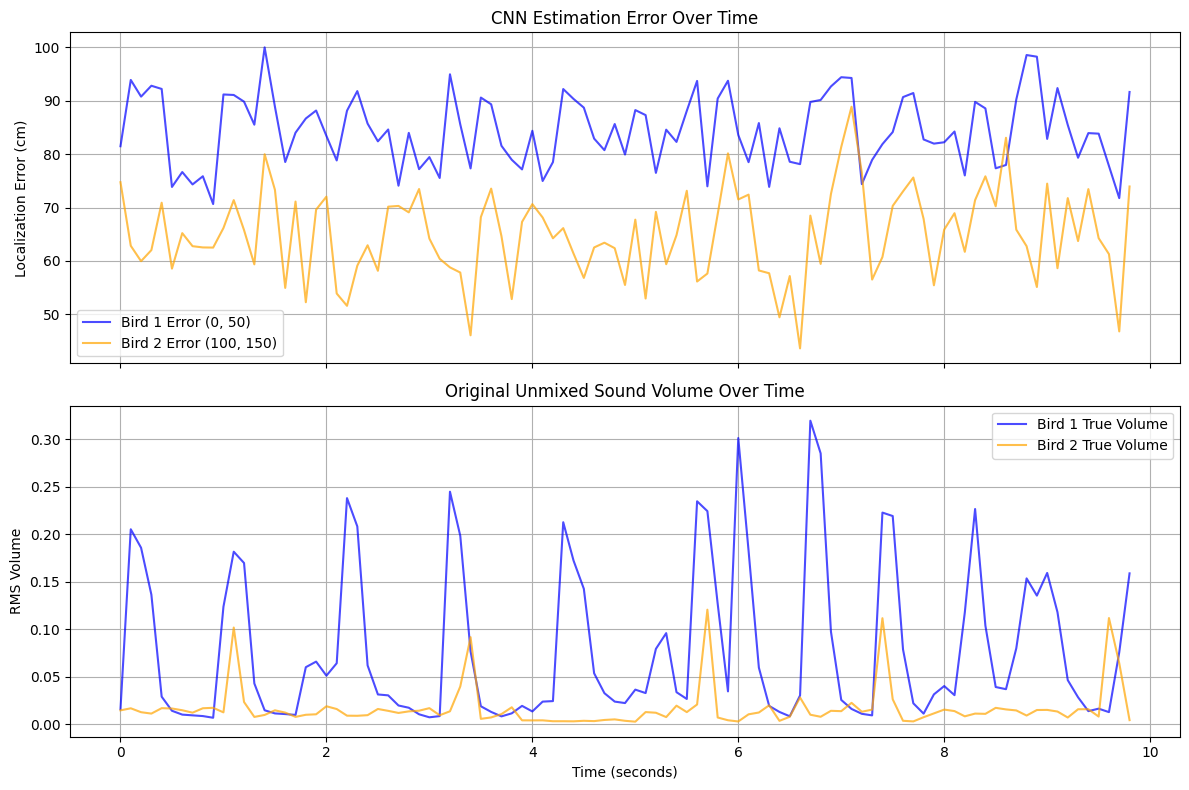

In [58]:
# 0.Load the model
arch, kernel_sizes, strides, mic_locs = [4, 32, 64, 128, 256], [128, 7, 5, 5, 3], [4, 4, 2, 2, 1], [(-45, 0), (-15,0), (15, 0),(45,0)]
model = NSourcesCNN(4, arch, strides, kernel_sizes, sum=False) 

# 2.1 (Optional best practice: add weights_only=True for security)
weights = torch.load(r'Submission\utils\results\N_sources_model_weights.pth', weights_only=True) 
model.load_state_dict(weights)


# 1. Set up the experiment
test_file_1:str = r"Submission\utils\assignment_2_dataset\test\XC1040774.mp3" 
test_file_2:str = r"Submission\utils\assignment_2_dataset\test\XC1043067.mp3" 


# 2 Decode the full files 
# ... (e.g., first 10 seconds to keep plotting manageable)
# 2.1 Decode the file
duration:float = 10.0 
decoder1 = AudioDecoder(test_file_1)
decoder2 = AudioDecoder(test_file_2)
wave1 = decoder1.get_samples_played_in_range(0, duration).data.mean(dim=0)
wave2 = decoder2.get_samples_played_in_range(0, duration).data.mean(dim=0)
# 2.2 Simulate the delays for the specific coordinates
# ... Simulate the delays for the specific coordinates (These return Python lists)
sim_wave1_list, _ = audio_simulator(wave1, source_loc=(0.0, 50.0), mic_locs=mic_locs)
sim_wave2_list, _ = audio_simulator(wave2, source_loc=(100.0, 150.0), mic_locs=mic_locs)
# 2.2.1 Helper function to trim and stack the list of 4 microphones into a 2D tensor
def prepare_mic_tensor(wave_list):
    min_l = min([w.shape[0] for w in wave_list])
    return torch.stack([w[:min_l] for w in wave_list])
sim_wave1 = prepare_mic_tensor(sim_wave1_list) # Convert lists to 2D tensors -> Shape: [4, samples]
sim_wave2 = prepare_mic_tensor(sim_wave2_list) # Convert lists to 2D tensors -> Shape: [4, samples]
# 2.3 Mix them together
min_len = min(sim_wave1.shape[1], sim_wave2.shape[1])
mixed_wave = sim_wave1[:, :min_len] + sim_wave2[:, :min_len]
# 3. THE SLIDING WINDOW INFERENCE ---
window_size = 4800 # 0.1 seconds at 48kHz
num_windows = min_len // window_size
errors_b1, errors_b2 = [], []
vols_b1, vols_b2 = [], []
time_axis = []

model.eval()
with torch.no_grad():
    for i in range(num_windows):
        start = i * window_size
        end = start + window_size
        
        # 2a. Process the chunk exactly like the DataLoader does
        chunk = mixed_wave[:, start:end]
        chunk = chunk - chunk.mean(dim=1, keepdim=True)
        scale = chunk.pow(2).mean().sqrt().clamp_min(1e-8)
        chunk = chunk / scale
        chunk = chunk.unsqueeze(0) # Add batch dimension -> [1, 4, 4800]
        
        # 2b. Make Prediction
        output = model(chunk)
        pred_coords = output[:, :6]
        preds_cm = denormalize_predictions(pred_coords, mins_6, maxs_6).squeeze()
        
        # 2c. Map Predictions to Targets (Because we sorted Left-to-Right!)
        # Target 1 is X=0, Target 2 is X=100. 
        # Therefore, the network's first output is Bird 1, second is Bird 2.
        pred_b1 = preds_cm[0:2] 
        pred_b2 = preds_cm[2:4]
        
        # 2d. Calculate CM Error
        err1 = torch.norm(pred_b1 - torch.tensor([0.0, 50.0])).item()
        err2 = torch.norm(pred_b2 - torch.tensor([100.0, 150.0])).item()
        errors_b1.append(err1)
        errors_b2.append(err2)
        
        # 2e. Calculate True Original Volume (RMS Energy) for this 0.1s window
        vol1 = wave1[start:end].pow(2).mean().sqrt().item()
        vol2 = wave2[start:end].pow(2).mean().sqrt().item()
        vols_b1.append(vol1)
        vols_b2.append(vol2)
        
        time_axis.append(start / 48000) # Convert samples back to seconds

# --- 3. PLOTTING THE RESULTS ---
fig, (ax1, ax2) = PLT.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot Error
ax1.plot(time_axis, errors_b1, label='Bird 1 Error (0, 50)', color='blue', alpha=0.7)
ax1.plot(time_axis, errors_b2, label='Bird 2 Error (100, 150)', color='orange', alpha=0.7)
ax1.set_ylabel('Localization Error (cm)')
ax1.set_title('CNN Estimation Error Over Time')
ax1.legend()
ax1.grid(True)

# Plot Volume
ax2.plot(time_axis, vols_b1, label='Bird 1 True Volume', color='blue', alpha=0.7)
ax2.plot(time_axis, vols_b2, label='Bird 2 True Volume', color='orange', alpha=0.7)
ax2.set_ylabel('RMS Volume')
ax2.set_xlabel('Time (seconds)')
ax2.set_title('Original Unmixed Sound Volume Over Time')
ax2.legend()
ax2.grid(True)

PLT.tight_layout()
PLT.show()

# Utils (helpers or static methods)

In [2]:
def normalize_targets(coords, mins, maxs):
    """Maps raw cm coordinates to a [-1, 1] range."""
    # Scale to [0, 1] first, then shift to [-1, 1]
    return 2.0 * (coords - mins) / (maxs - mins) - 1.0

def denormalize_predictions(preds, mins, maxs):
    """Maps [-1, 1] model outputs back to raw cm coordinates."""
    # Reverse shift from [-1, 1] to [0, 1], then scale back to cm
    return (preds + 1.0) / 2.0 * (maxs - mins) + mins

In [3]:
@staticmethod
def audio_simulator(input, source_loc:tuple, mic_locs:list|tuple):
    """
    Def:
    :params input
    :params tuple of floats source_loc: Holding the cartesian coordinates of the source; 
    :params list of tuples mic_locs: Holding the cartesian coordinates of multiple microphones. If all the microphones share the same location then the argument becomes a tuple

    Return: waveforms (visualiazation) and time_delays
    """

    def _time_delay_calculation(mic=mic_locs, source=source_loc, common_loc=False):
        for locations in mic:
            relative_time_delays.append(np.round((np.sqrt( (source[0]-locations[0])**2 + (source[1]-locations[1])**2)/c)*sr))

        # 2. Locate the furthest situated microphone by time_delay: the more samples, the furthest
        furtherst = max(relative_time_delays)
        for relative_time in relative_time_delays:
            delay = furtherst-relative_time
            waveforms.append(input[int(delay):])
    
    c:int=340*100
    sr:int = 48000
    relative_time_delays:list = []
    time_delay_of_arival:int = 0
    waveforms:list = []

    if isinstance(mic_locs, tuple):
        _time_delay_calculation(True)
    elif isinstance(mic_locs, list):
        _time_delay_calculation()
    
    
    return waveforms, relative_time_delays

In [4]:
class CustomAudioDecoderData(Dataset):
    """
    :param float t:
    :param list of integers mic_locs:
    :param tuple holding float values n_sources_min_max:
    ....
    """
    def __init__(self, t, mic_locs, n_sources_min, n_sources_max, 
                 x_loc_min, x_loc_max, y_loc_min, y_loc_max, 
                 split='train', epoch_len:int=2560,
                 data_folder=dataset_roots, transforms:bool = None, random_assignment:bool=True, dynamic:bool=True):

        # 1.1 Fail save, ensuring NO-CAPITAL charachters are accidentally inserted;        
        self.split = split.lower()
        # 1.2 Map split string to the correct index of data_folder (0=train, 1=val, 2=test)
        split_mapping = {'train': 0, 'val': 1, 'test': 2}
        if self.split not in split_mapping:
            raise ValueError("split must be 'train', 'val', or 'test'")
        # 1.3 Set a value (e.g., 0, 1 or 2) based on the subset of interest specified at class instantiation time;
        self.split_idx = split_mapping[self.split]

        self.dataset_root_paths = data_folder
        self.transform = transforms
        self.end_time = t/1000 
        self.mic_locs = mic_locs
        self.n_sources = (n_sources_min, n_sources_max)
        self.x_y_min_max = (x_loc_min, x_loc_max, y_loc_min, y_loc_max)
        self.rdm_assign = random_assignment
        self.dynamic = dynamic
        self.epoch_len = epoch_len

        # 1. Collecting data paths
        all_data_paths = self._retrieve_and_assemble_data_paths()

        # 2. Declare active file paths based on step `1.3`
        self.active_paths = all_data_paths[self.split_idx]
    
    def __len__(self):
        return self.epoch_len

    def __getitem__(self, idx):

        # 3.1 Determine how many sources;
        n_sources = rdm.randint(self.n_sources[0], self.n_sources[1])
        # 3.2 Create data holders aka containers;
        all_simulated_waveforms, source_locations = [], []
        # 4. Loop over sources
        for _ in range(n_sources):
            # 4.1 Target a single file path string using the index [1] and a randomly chosen index [rdm]
            file_path = rdm.choice(self.active_paths)
            # 4.2 Assign and save/append the randomly generated coordinates of the sources
            if self.rdm_assign:
                x, y = rdm.uniform(self.x_y_min_max[0], self.x_y_min_max[1]), rdm.uniform(self.x_y_min_max[2], self.x_y_min_max[3])
            else:
                x = self.x_y_min_max[0]
                y = self.x_y_min_max[2]

            source_locations.append((x,y))
            # 4.3 Safely instantiate AudioDecoder with a single string path [1]
            decoder = AudioDecoder(file_path)
            if self.transform:
                # 4.4 Extract audio tensor stream and cut adequately
                waveform = decoder.get_samples_played_in_range(start_seconds=0, stop_seconds=self.end_time) # Length of the returned sample
                #TODO Implement if statement to check for the number of channels
                mono = torch.mean(waveform.data, dim=0) # Averaging the waveform holding at least two channels
                waveforms, delays = audio_simulator(mono, source_loc=(x, y), mic_locs=self.mic_locs) 
                # 4.4.1 Find the samllest length in the list of waveforms
                # ... then use it as a refference for a clamping threshold
                min_length = min([w.shape[0] for w in waveforms])
                # 4.4.2 Trim every waveform to match that minimum length
                trimmed_waveforms = [w[:min_length] for w in waveforms] # Shape waveforms:  [torch.tensor(simmulated waveform) for wave in range(no. mics)]
                # 4.4.3 Stack the trimmed waveforms                     # 
                source_tensor = torch.stack(trimmed_waveforms) # Shape: [n_mics, samples]
                all_simulated_waveforms.append(source_tensor)
                # # Debug statement 2
                # print("Waveform-decoder shape {}\n"
                # "Waveforms-decoder after mono p[ shape {}\n" \
                # "Waveforms after audio simulator and trimming {} plus size of each element {}\n" \
                # "First stacking (torch.stack(trimmed_waveforms)): {}" \
                # "".format(waveform.data.shape, mono.shape, 
                #             len(trimmed_waveforms),(trimmed_waveforms[0].shape, 
                #                                     trimmed_waveforms[1].shape),
                #                                     source_tensor.shape))

        # 5. After the 'for' loop ends a global loop comes into effect,
        # ... whose purpose is to level down all the samples
        if self.dynamic:
            global_min_length = min([w.shape[1] for w in all_simulated_waveforms])
        else:
            global_min_length=4800

        # 5.1 Compute the length of each waveform by using a conditioned list comprehension
        # 5.1.1 IF waveform length higher than global_min_length then chunk off the tail
        all_simulated_and_trimmed_waveforms = [w[:, :global_min_length] if w.shape[1] >= global_min_length 
        # 5.1.2 Else pad zeros starting from left to right
        else torch.nn.functional.pad(w, (0, global_min_length - w.shape[1])) for w in all_simulated_waveforms]
        
        # # Debug statement 3
        # print(all_simulated_waveforms)
        # print(all_simulated_and_trimmed_waveforms)
        # print("Initial len {} vs aftermath len{}".format(len(all_simulated_waveforms), len(all_simulated_and_trimmed_waveforms)))
        
        stacked_tensor = torch.stack(all_simulated_and_trimmed_waveforms) # Shape: [n_sources, n_mics, samples]
        mixed_tensor = torch.sum(stacked_tensor, dim=0)       # Shape: [n_mics, samples]      
        mixed_tensor = mixed_tensor - mixed_tensor.mean(dim=1, keepdim=True)
        scale = mixed_tensor.pow(2).mean().sqrt().clamp_min(1e-8)
        mixed_tensor=mixed_tensor/scale
        
        # 6 Redefining the torch shape structure to hold 7 elements, 
        # ... first 6 of which are representing X,Y pair coordinates for sources
        if self.n_sources[1]>1:
            # 6.1 Sort the sources by distance to the microphones (origin 0,0)
            # Sort purely by the X-coordinate (Left to Right) to ensure perfect label stability
            source_locations.sort(key=lambda loc: loc[0])
            target_locations = torch.zeros(7, dtype=torch.float32) # 6.2 Creates the dummy tensor with the reuqired size
            # 6.3 Fill the fixed tensor with the active, sorted coordinates
            for i, (x, y) in enumerate(source_locations):
                target_locations[i * 2] = x
                target_locations[i * 2 + 1] = y
            # 6.4. Store the actual number of sources in the very last index
            target_locations[6] = n_sources
        
        else:
            target_locations = torch.tensor(source_locations).squeeze()
        
        # Informative staement
        # print("Second stacking:",stacked_tensor.shape)
        # print("Third stacking:",mixed_tensor.shape)
        # print("Source tensor shape {} Stacked tensor shape {} Source locations {}".format(source_tensor.shape, stacked_tensor.shape, source_locations))
        
        if self.dynamic:
            return source_tensor, stacked_tensor, source_locations, delays
        else:
             return mixed_tensor, target_locations
  
    def _retrieve_and_assemble_data_paths(self, info:bool=False):
        # 0. Declaring path containers;
        _p_dataset:list = []
        # 1. Determining the number of data sets we're interested in
        # ... commonly stays 3: train, test, val;
        for set in range(len(dataset_roots)):
            # 1.1. Retriveing the .mp3 file names
            names = os.listdir(self.dataset_root_paths[set])
            _p_dataset.append([os.path.join(self.dataset_root_paths[set],item) for item in names])

        if info:
            print(f"Container holding pahts to .mp3 files holds the following content {_p_dataset}")

        return _p_dataset


# Tests

tensor(-8.5179) tensor(11.6148)


(array([1.60000e+01, 1.60000e+01, 0.00000e+00, 1.00000e+01, 2.20000e+01,
        1.60000e+01, 7.00000e+00, 2.20000e+01, 2.20000e+01, 6.10000e+01,
        5.40000e+01, 7.30000e+01, 3.10000e+01, 5.10000e+01, 4.70000e+01,
        6.30000e+01, 1.65000e+02, 1.55000e+02, 1.80000e+02, 2.11000e+02,
        2.64000e+02, 3.95000e+02, 4.88000e+02, 7.47000e+02, 5.83000e+02,
        8.68000e+02, 1.15100e+03, 1.86800e+03, 2.63000e+03, 4.18900e+03,
        6.46200e+03, 7.79400e+03, 1.57190e+04, 1.60210e+04, 1.94020e+04,
        2.24680e+04, 2.61780e+04, 3.01260e+04, 3.61840e+04, 4.01760e+04,
        4.43120e+04, 1.24269e+05, 5.19688e+05, 5.27720e+04, 4.06590e+04,
        3.52700e+04, 2.91060e+04, 2.62750e+04, 2.34820e+04, 2.12040e+04,
        1.67440e+04, 1.64440e+04, 1.42130e+04, 9.66300e+03, 5.33600e+03,
        3.97100e+03, 2.49100e+03, 1.43500e+03, 1.32500e+03, 9.70000e+02,
        6.97000e+02, 5.57000e+02, 5.52000e+02, 4.64000e+02, 2.07000e+02,
        2.40000e+02, 2.18000e+02, 1.76000e+02, 9.90

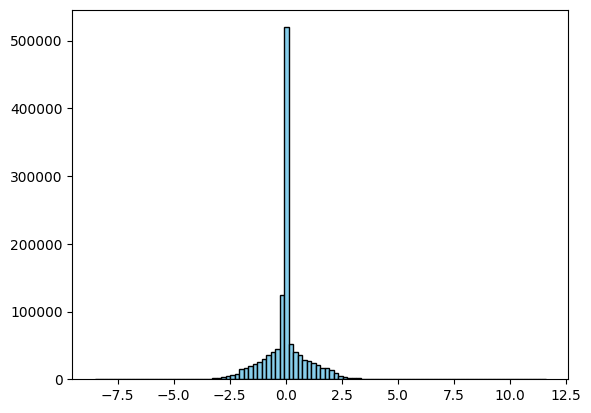

In [9]:
sample=next(enumerate(trainLoader))
_,waveform = sample
data_flattened = waveform[0].flatten()
print(data_flattened.min(), data_flattened.max())
PLT.hist(data_flattened.cpu().numpy(), bins=100, color='skyblue', edgecolor='black')
